<a href="https://colab.research.google.com/github/zeenah-bio/medical-appointment-no-show-prediction/blob/main/NoShow_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medical Appointment No-Show Analysis and Prediction

---



---



---

🚩

## Introduction
This notebook presents an academic medical data analysis and machine learning project based on a real healthcare appointment dataset.  
The project focuses on understanding why some patients fail to attend their scheduled medical appointments (**No-show**) and how this behavior can be analyzed and predicted using data-driven methods.

From a **Biomedical Informatics** perspective, this topic is important because missed appointments can negatively affect hospital workflow, physician time allocation, patient access to care, and healthcare resource management. Therefore, predicting no-show behavior may support better scheduling strategies and improved healthcare service efficiency.

## Project Aim:
✨
The main aim of this project is to:
- explore the medical appointment dataset,
- understand its structure and variables,
- identify important data quality issues,
- prepare the data for machine learning,
- and later build a predictive model to classify whether a patient is likely to attend or miss an appointment.

## Academic Relevance
This project is suitable for **Biomedical Informatics** because it combines:
- healthcare administrative data,
- patient-related factors,
- data preprocessing and quality assessment,
- machine learning for decision support,
- and interpretation of results in a real healthcare context.

## Dataset Source
The dataset used in this project is the **Medical Appointment No Shows** dataset, which contains information about medical appointments and whether patients attended them or not.

## Expected Workflow
This project will proceed in several academic phases:
1. Understanding the dataset
2. Exploring the data
3. Detecting data problems
4. Data preprocessing and cleaning
5. Feature engineering
6. Machine learning model selection
7. Model training and evaluation
8. Visualization and interpretation
9. Final academic conclusion

#1.***Importing Libraries and Loading the Dataset***

---







In this section, we import the required Python libraries and load the dataset into Google Colab for initial inspection.

In [391]:
# ================================
# Import required libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import(train_test_split,StratifiedKFold,
    cross_val_score)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)
from xgboost import XGBClassifier
# To load the dataset, you first need to upload 'KaggleV2-May-2016.csv' to your Colab environment.
# Load dataset from local repository

url = "https://raw.githubusercontent.com/zeenah-bio/medical-appointment-no-show-prediction/main/data/KaggleV2-May-2016.csv"
df = pd.read_csv(url)

# Display first 5 rows of the dataset
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [392]:
# Check the shape of the dataset (rows, columns)
df.shape



(110527, 14)

In [393]:
# Display column names
df.columns


Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')

In [394]:
# Get dataset information (data types + null values)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [395]:
# Summary statistics of numerical columns
df.describe()


,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [396]:
# Check distribution of target variable
df["No-show"].value_counts()


,count
No-show,
No,88208
Yes,22319


In [397]:
# Percentage distribution of target variable
df["No-show"].value_counts(normalize=True)

,proportion
No-show,
No,0.798067
Yes,0.201933


The dataset shows a class imbalance, where the majority of patients attend their appointments, while a smaller portion miss them. This imbalance should be considered later when evaluating model performance.

# 2. *Data Quality Assessment*

---


In this section, we examine the dataset to identify potential data quality issues such as missing values, duplicates, invalid entries, and inconsistencies before performing preprocessing.

In [398]:
# Check for missing values in each column
df.isnull().sum()

,0
PatientId,0
AppointmentID,0
Gender,0
ScheduledDay,0
AppointmentDay,0
Age,0
Neighbourhood,0
Scholarship,0
Hipertension,0
Diabetes,0


In [399]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [400]:
# Check age values
df["Age"].describe()

,Age
count,110527.000000
mean,37.088874
std,23.110205
min,-1.000000
25%,18.000000
50%,37.000000
75%,55.000000
max,115.000000


In [401]:
# Check unique values in No-show
df["No-show"].unique()

array(['No', 'Yes'], dtype=object)

In [402]:
df["Gender"].unique()


array(['F', 'M'], dtype=object)

In [403]:
df["Neighbourhood"].nunique()

81

In [404]:
df[["ScheduledDay", "AppointmentDay"]].head()

,ScheduledDay,AppointmentDay
0,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z
1,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z
2,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z
3,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z
4,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z


In [405]:
df["No-show"].value_counts()

,count
No-show,
No,88208
Yes,22319


In [406]:
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')

## Data Quality Issues Identified:
❌

The following issues were identified during the data quality assessment:

1. No explicit missing values were detected, but further validation is required.
2. Some invalid values exist, such as negative age (-1), which is not realistic.
3. Date columns (ScheduledDay and AppointmentDay) are stored as text and need conversion to datetime format.
4. Some columns (PatientId, AppointmentID) are identifiers and may not be useful for prediction.
5. Certain categorical variables require encoding.
6. Column names contain spelling inconsistencies (e.g., Hipertension, Handcap).
7. There is a class imbalance in the target variable (No-show).

#  3. *Data Preprocessing*
---


In this section, the dataset is cleaned and prepared for machine learning. This includes renaming columns, handling invalid values, converting date columns, creating useful features, and removing non-informative identifiers.

In [407]:
# Create a working copy of the dataset
df_clean = df.copy()

In [408]:
# Rename columns for clarity and consistency
df_clean = df_clean.rename(columns={
    "Hipertension": "Hypertension",
    "Handcap": "Handicap",
    "No-show": "No_show"
})

# Display updated column names
df_clean.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No_show'],
      dtype='object')

In [409]:
# Convert date columns to datetime format
df_clean["ScheduledDay"] = pd.to_datetime(df_clean["ScheduledDay"])
df_clean["AppointmentDay"] = pd.to_datetime(df_clean["AppointmentDay"])

# Confirm the conversion
df_clean[["ScheduledDay", "AppointmentDay"]].dtypes

,0
ScheduledDay,"datetime64[ns, UTC]"
AppointmentDay,"datetime64[ns, UTC]"


In [410]:
# Create a waiting time feature in days
df_clean["WaitingDays"] = (
    df_clean["AppointmentDay"].dt.normalize() -
    df_clean["ScheduledDay"].dt.normalize()
).dt.days

# Display sample values
df_clean[["ScheduledDay", "AppointmentDay", "WaitingDays"]].head()

,ScheduledDay,AppointmentDay,WaitingDays
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,0
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,0
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,0
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,0
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,0


In [411]:
# Check for negative waiting times
(df_clean["WaitingDays"] < 0).sum()

np.int64(5)

In [412]:
# Inspect rows with negative waiting days
df_clean[df_clean["WaitingDays"] < 0][["ScheduledDay", "AppointmentDay", "WaitingDays"]].head()

,ScheduledDay,AppointmentDay,WaitingDays
27033,2016-05-10 10:51:53+00:00,2016-05-09 00:00:00+00:00,-1
55226,2016-05-18 14:50:41+00:00,2016-05-17 00:00:00+00:00,-1
64175,2016-05-05 13:43:58+00:00,2016-05-04 00:00:00+00:00,-1
71533,2016-05-11 13:49:20+00:00,2016-05-05 00:00:00+00:00,-6
72362,2016-05-04 06:50:57+00:00,2016-05-03 00:00:00+00:00,-1


In [413]:
# Remove rows with negative waiting days
df_clean = df_clean[df_clean["WaitingDays"] >= 0]

In [414]:
# Check invalid age values
(df_clean["Age"] < 0).sum()

np.int64(1)

In [415]:
# Remove rows with invalid negative age
df_clean = df_clean[df_clean["Age"] >= 0]

In [416]:
# Drop identifier columns that are not useful for prediction
df_clean = df_clean.drop(columns=["PatientId", "AppointmentID"])

In [417]:
# Encode target variable: Yes = 1 (missed), No = 0 (attended)
df_clean["No_show"] = df_clean["No_show"].map({"No": 0, "Yes": 1})

# Verify target encoding
df_clean["No_show"].value_counts()

,count
No_show,
0,88207
1,22314


In [418]:
# Extract appointment day of week
df_clean["AppointmentWeekday"] = df_clean["AppointmentDay"].dt.day_name()

# Check sample values
df_clean["AppointmentWeekday"].head()

,AppointmentWeekday
0,Friday
1,Friday
2,Friday
3,Friday
4,Friday


In [419]:
# Extract scheduled day of week
df_clean["ScheduledWeekday"] = df_clean["ScheduledDay"].dt.day_name()

# Check sample values
df_clean["ScheduledWeekday"].head()

,ScheduledWeekday
0,Friday
1,Friday
2,Friday
3,Friday
4,Friday


In [420]:
# Check dataset shape after preprocessing steps
df_clean.shape

(110521, 15)

In [421]:
# Final quick inspection after initial preprocessing
df_clean.head()

,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No_show,WaitingDays,AppointmentWeekday,ScheduledWeekday
0,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,0,0,Friday,Friday
1,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,0,0,Friday,Friday
2,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,0,0,Friday,Friday
3,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,0,Friday,Friday
4,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,0,0,Friday,Friday


## Summary of Preprocessing Performed:
✅

The following preprocessing steps were completed:
- Renamed inconsistent column names for clarity
- Converted date columns into datetime format
- Created a new feature representing waiting time in days
- Removed records with invalid waiting times
- Removed records with invalid negative age values
- Dropped identifier columns not useful for prediction
- Extracted weekday-related features from the date columns
- Encoded the target variable into numerical format

### Handling Categorical Variables (Neighbourhood Encoding)

The Neighbourhood feature was encoded using one-hot encoding (pd.get_dummies), resulting in approximately 80 binary features.

While this method preserves all categorical information without introducing ordinal bias, it significantly increases the dimensionality of the dataset.

Alternative encoding techniques such as target encoding or frequency encoding could reduce dimensionality and potentially improve model performance. However, one-hot encoding was selected in this implementation for its simplicity and interpretability.

This decision reflects a trade-off between model simplicity and computational efficiency, which is important in real-world applications.




These steps improved the dataset quality and prepared it for exploratory analysis and machine learning.

# 4. ***Exploratory Data Analysis (EDA)***

---


In this section, we explore the dataset visually and statistically to understand patterns, relationships, and key factors influencing patient attendance behavior.

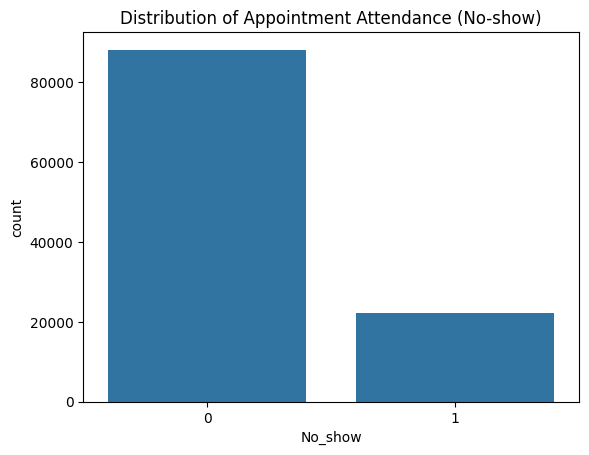

In [422]:
# Plot target distribution
sns.countplot(x="No_show", data=df_clean)
plt.title("Distribution of Appointment Attendance (No-show)")
plt.show()

The dataset shows that the majority of patients attend their appointments, while a smaller proportion miss them. This indicates a class imbalance, which should be considered during model evaluation.

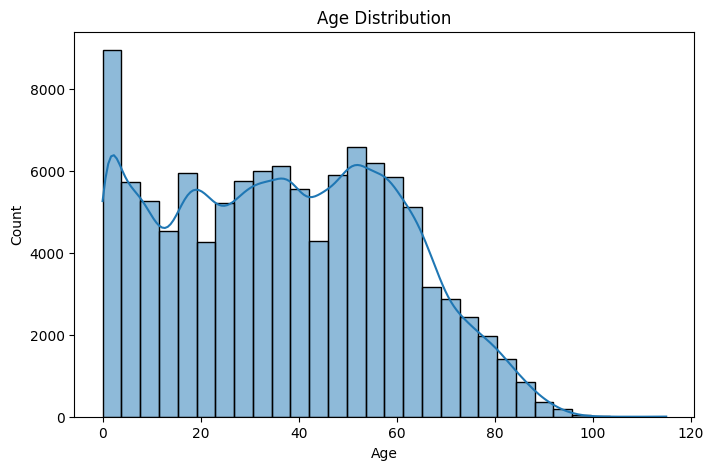

In [423]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

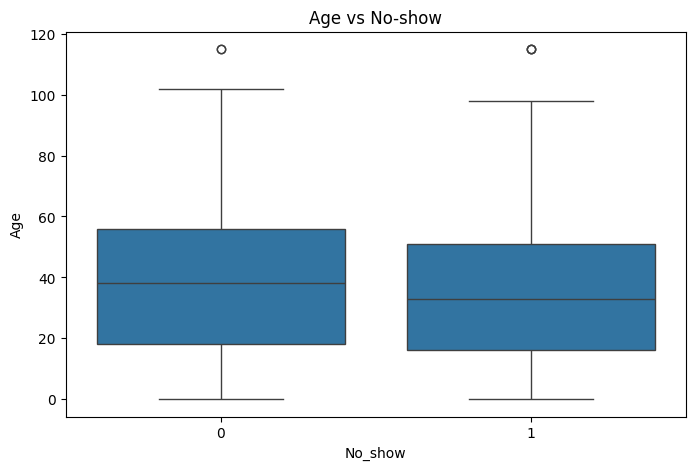

In [424]:
plt.figure(figsize=(8,5))
sns.boxplot(x="No_show", y="Age", data=df_clean)
plt.title("Age vs No-show")
plt.show()

### Age Interpretation

The boxplot indicates that the age distributions of patients who attended and those who missed their appointments are broadly similar, with only a slight difference in median age. Patients in the no-show group appear to be marginally younger on average.

This suggests that age may have some association with attendance behavior; however, the substantial overlap between the two groups indicates that age alone does not strongly differentiate between attending and non-attending patients.

In practical terms, younger individuals may face more scheduling variability or competing commitments, but this effect appears limited. Therefore, age should be interpreted as a secondary contributing factor rather than a dominant driver of no-show behavior

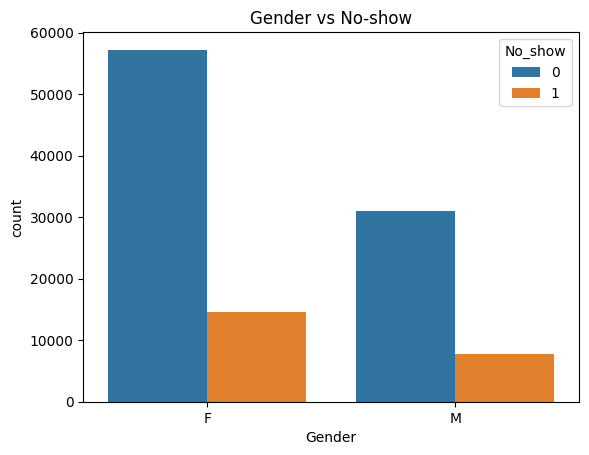

In [425]:
sns.countplot(x="Gender", hue="No_show", data=df_clean)
plt.title("Gender vs No-show")
plt.show()

### Gender Interpretation

The plot shows that female patients constitute a larger portion of the dataset and therefore account for a higher number of both attended and missed appointments in absolute terms.

However, this pattern should not be interpreted as evidence that gender directly influences no-show behavior. The observed difference is likely driven by the underlying distribution of patients rather than a true behavioral distinction.

To properly assess the role of gender, proportional comparisons would be required. Based on the current visualization, gender appears to have limited explanatory significance relative to other factors.

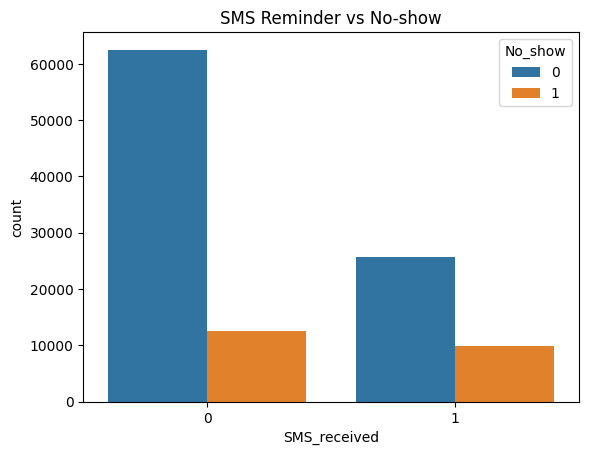

In [426]:
sns.countplot(x="SMS_received", hue="No_show", data=df_clean)
plt.title("SMS Reminder vs No-show")
plt.show()

### SMS Reminder Interpretation

The plot suggests that patients who did not receive SMS reminders are associated with a higher number of missed appointments, indicating a potential relationship between reminder systems and improved attendance.

However, this relationship should be interpreted with caution. The assignment of SMS reminders is not necessarily random and may depend on operational factors such as scheduling practices or waiting time. In particular, patients with longer waiting periods may be more likely to receive reminders while also being more prone to missing appointments.

This introduces the possibility of confounding, where the observed effect of SMS reminders may partially reflect the influence of other variables. Therefore, while reminders appear beneficial, the extent of their independent impact cannot be fully determined from this analysis alone.

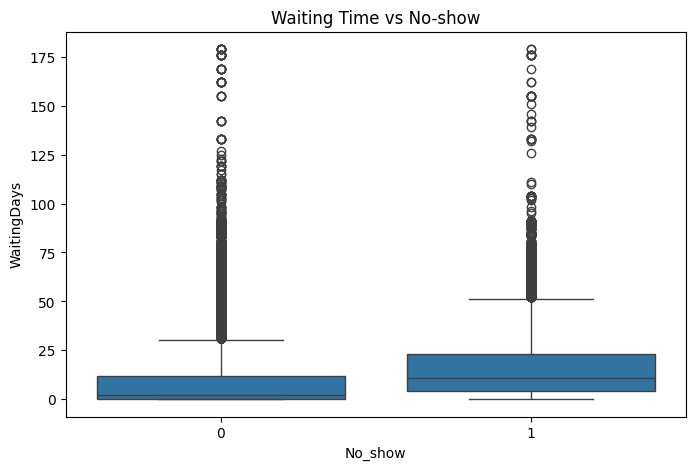

In [427]:
plt.figure(figsize=(8,5))
sns.boxplot(x="No_show", y="WaitingDays", data=df_clean)
plt.title("Waiting Time vs No-show")
plt.show()

### Waiting Time Interpretation

The boxplot shows a clear difference between the two groups, with patients in the no-show category exhibiting noticeably longer waiting times compared to those who attended their appointments.

This indicates a strong association between waiting time and missed appointments. Longer delays between scheduling and the appointment date may reduce patient commitment, increase the likelihood of forgetting, or allow patients to seek alternative care.

Additionally, waiting time may influence other variables, such as the likelihood of receiving SMS reminders, making it a potential confounding factor in the analysis.

Overall, this finding highlights the importance of operational efficiency, suggesting that reducing waiting time could play a key role in improving appointment attendance.

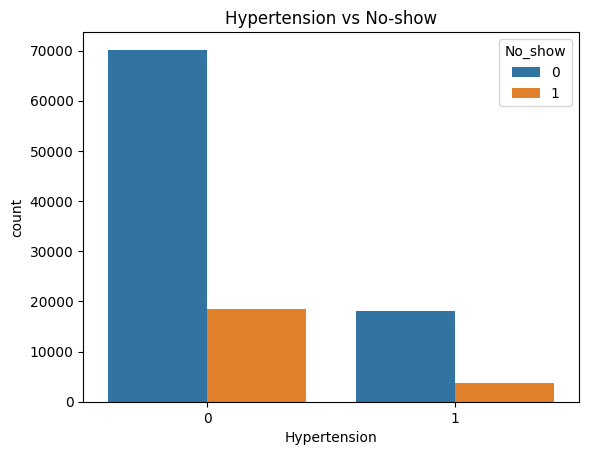

In [428]:
sns.countplot(x="Hypertension", hue="No_show", data=df_clean)
plt.title("Hypertension vs No-show")
plt.show()

### Hypertension Interpretation

The plot shows that most patients do not have hypertension, and therefore they account for the majority of both attended and missed appointments. Patients with hypertension appear to have fewer missed appointments in absolute terms.

This pattern may suggest that individuals with chronic conditions are more consistent in attending appointments, possibly due to the perceived importance of ongoing medical care.

However, this relationship should be interpreted cautiously. Hypertension is often associated with age and increased healthcare engagement, which may themselves influence attendance behavior. As a result, hypertension may act as an indirect indicator rather than a direct influencing factor.

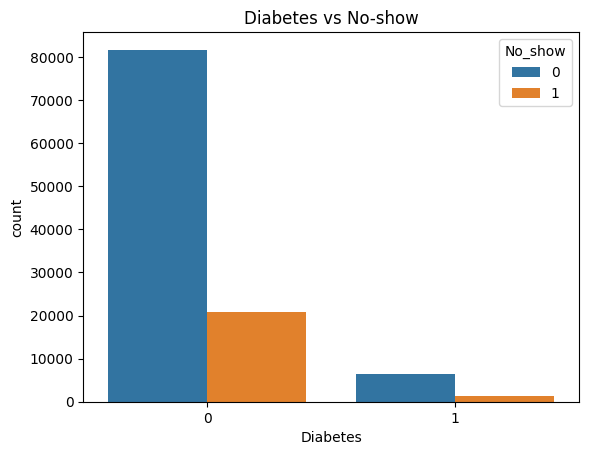

In [458]:
sns.countplot(x="Diabetes", hue="No_show", data=df_clean)
plt.title("Diabetes vs No-show")
plt.show()

### Diabetes Interpretation

The plot indicates that patients without diabetes form the majority of the dataset and therefore contribute the largest number of missed appointments in absolute terms. Patients with diabetes appear to have relatively fewer no-show cases.

This may suggest that individuals with chronic conditions are more likely to attend their appointments due to the need for regular monitoring and management.

However, this pattern should not be interpreted as an independent effect of diabetes. The observed association may reflect underlying factors such as age, comorbidity burden, and healthcare engagement.

Therefore, diabetes may function more as a marker of ongoing healthcare need rather than a direct factor influencing attendance behavior.

### Key Insights from Exploratory Data Analysis (EDA)

The exploratory analysis highlights several key patterns in the dataset.

A clear class imbalance is observed, with most patients attending their appointments. Waiting time shows the strongest association with no-show behavior, where longer delays are linked to higher absence rates, emphasizing the role of operational factors.

SMS reminders appear to be associated with improved attendance; however, this relationship may be confounded by waiting time and should be interpreted cautiously.

In contrast, demographic variables such as age and gender show limited differentiation between groups. Similarly, chronic conditions (e.g., diabetes and hypertension) may be associated with better attendance, but this likely reflects underlying factors such as healthcare engagement rather than a direct effect.

Overall, the analysis suggests that scheduling-related and behavioral factors are more influential than static demographic characteristics, providing a basis for subsequent modelling steps

# 5.***Feature Preparation and Data Splitting***

---






In this section, the dataset is prepared for machine learning by selecting relevant features, encoding categorical variables, and splitting the data into training and testing sets.

In [430]:
# Define target variable
y = df_clean["No_show"]

# Define feature set (drop target column)
X = df_clean.drop(columns=["No_show"])

In [431]:
# Drop raw date columns (we already extracted useful features)
X = X.drop(columns=["ScheduledDay", "AppointmentDay"])

In [432]:
# Convert categorical variables using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

In [433]:
X.shape

(110521, 99)

In [434]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [435]:
print(X_train.shape)
print(X_test.shape)

(88416, 99)
(22105, 99)


## Data Preparation Summary

At this stage, the dataset has been fully prepared for machine learning:
- Target variable was separated from input features
- Irrelevant columns were removed
- Categorical variables were encoded into numerical format
- The dataset was split into training and testing sets

The data is now ready for model training.

# 6. ***Model Training (Logistic Regression)***

---


In this section, a baseline classification model is trained to predict appointment no-show behavior.

In [436]:
model = LogisticRegression(max_iter=1000)

In [437]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [438]:
y_pred = model.predict(X_test)

In [439]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.99      0.89     17642
           1       0.38      0.02      0.03      4463

    accuracy                           0.80     22105
   macro avg       0.59      0.50      0.46     22105
weighted avg       0.71      0.80      0.71     22105



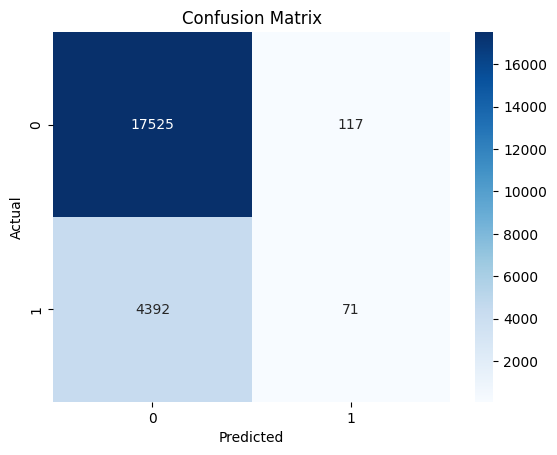

In [440]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Model Evaluation Insights

The logistic regression model achieved an overall accuracy of 80%, which appears acceptable at first glance. However, a deeper analysis reveals significant limitations.

The model performs very well in predicting patients who attend appointments (class 0), achieving a recall of 99%. In contrast, it performs poorly in identifying patients who miss appointments (class 1), with a recall of only 2%.

This indicates that the model is heavily biased toward the majority class, likely due to class imbalance in the dataset. As a result, the model tends to predict most patients as attending, failing to effectively capture no-show cases.

Therefore, accuracy alone is not a reliable metric in this scenario, and additional techniques are required to improve model performance, particularly for the minority class.

# 7. Model Improvement

---


In this section, model performance is improved by addressing class imbalance and testing a more advanced algorithm.

In [441]:
# Improved model with class_weight
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')

# Train
model_balanced.fit(X_train, y_train)

# Predict
y_pred_balanced = model_balanced.predict(X_test)

In [442]:
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.86      0.67      0.76     17642
           1       0.31      0.58      0.40      4463

    accuracy                           0.65     22105
   macro avg       0.59      0.63      0.58     22105
weighted avg       0.75      0.65      0.68     22105



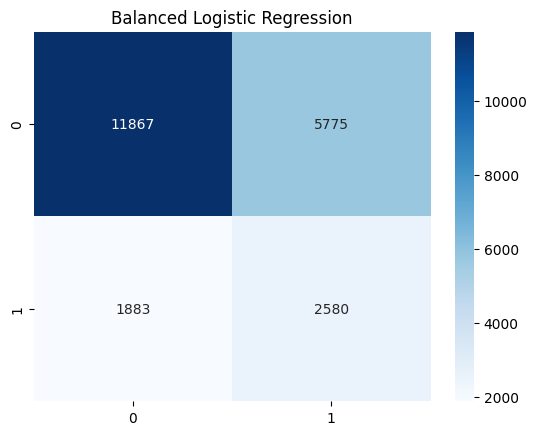

In [443]:
cm = confusion_matrix(y_test, y_pred_balanced)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Balanced Logistic Regression")
plt.show()

## Improved Model Insights

After applying class balancing, the logistic regression model showed a significant improvement in detecting no-show cases.

The recall for the no-show class increased from 2% to 58%, indicating a much better ability to identify patients who are likely to miss their appointments.

However, this improvement came at the cost of reduced overall accuracy and an increase in false positive predictions. This trade-off is expected when handling class imbalance.

Overall, the balanced model provides a more meaningful and practical solution, as identifying no-show patients is more critical than simply maximizing accuracy.

In [444]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [445]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87     17642
           1       0.39      0.21      0.28      4463

    accuracy                           0.78     22105
   macro avg       0.61      0.56      0.57     22105
weighted avg       0.74      0.78      0.75     22105



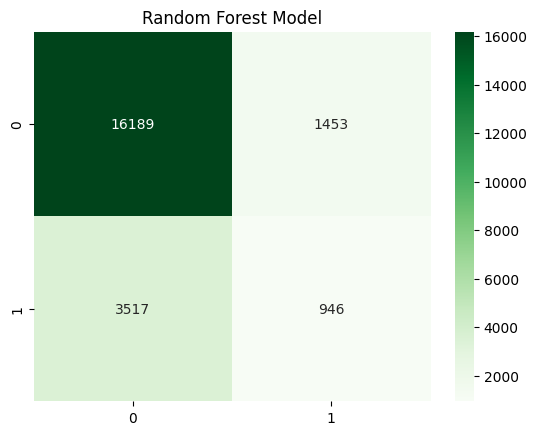

In [446]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Model")
plt.show()

### Handling Class Imbalance in XGBoost

To address class imbalance, the `scale_pos_weight` parameter was calculated dynamically from the training data as the ratio of negative to positive samples.

This allows the model to place more emphasis on the minority class (no-show cases), improving its ability to detect missed appointments in an imbalanced dataset.

In [447]:
# Compute class imbalance ratio from the training set
neg = sum(y_train == 0)
pos = sum(y_train == 1)

scale_pos_weight = neg / pos

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 3.952999831942188


In [448]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

In [449]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [450]:
y_pred_xgb = xgb_model.predict(X_test)

In [451]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.92      0.53      0.68     17642
           1       0.31      0.82      0.45      4463

    accuracy                           0.59     22105
   macro avg       0.62      0.68      0.56     22105
weighted avg       0.80      0.59      0.63     22105



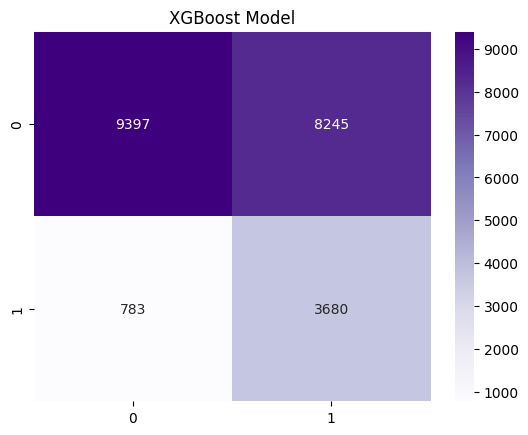

In [452]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Purples")
plt.title("XGBoost Model")
plt.show()

The confusion matrix reveals that the model correctly identifies a large number of no-show cases (True Positives = 3680) while maintaining a relatively low number of missed no-show cases (False Negatives = 783). This indicates strong sensitivity (recall) toward the minority class, which is the primary objective in this study.

However, the number of False Positives (8245) is considerably high, meaning that many patients who would attend are incorrectly predicted as no-show. This behavior is expected due to the use of class imbalance handling (scale_pos_weight), which biases the model toward detecting the minority class.

Overall, the model prioritizes minimizing false negatives over false positives, which is appropriate in healthcare scenarios where failing to identify high-risk patients is more critical than issuing unnecessary alerts.


## Cross-Validation Evaluation
To obtain a more robust estimate of model performance, stratified k-fold cross-validation was applied to the final selected model (XGBoost).

In [453]:
# Define stratified k-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Recreate the final XGBoost model
xgb_cv_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=4,
    random_state=42,
    eval_metric='logloss'
)

# Cross-validation using recall because detecting no-show is the main goal
cv_recall_scores = cross_val_score(
    xgb_cv_model,
    X_train,
    y_train,
    cv=cv,
    scoring='recall'
)


print("Cross-validation recall scores:", cv_recall_scores)
print("Mean CV recall:", cv_recall_scores.mean())
print("Standard deviation:", cv_recall_scores.std())

Cross-validation recall scores: [0.81321759 0.82184874 0.80756303 0.81568627 0.83473389]
Mean CV recall: 0.8186099037766883
Standard deviation: 0.009275034525380355


### Cross-Validation Results Interpretation
The cross-validation results demonstrate that the model achieves a consistently high recall across all folds, with a mean recall of approximately 0.82 and a very low standard deviation (~0.009).

This indicates that the model's performance is stable and not sensitive to variations in the training data. The low variance suggests strong generalization ability and confirms that the model is not overfitting to a specific train-test split.

These findings strengthen the reliability of the model and support its robustness in identifying no-show cases across different subsets of the dataset.


## ROC Curve and AUC Evaluation

---



To further evaluate model performance, the Receiver Operating Characteristic (ROC) curve and the Area Under the Curve (AUC) were calculated. These metrics provide a comprehensive assessment of the model's ability to distinguish between no-show and show cases across different classification thresholds.

AUC Score: 0.7318174846690049


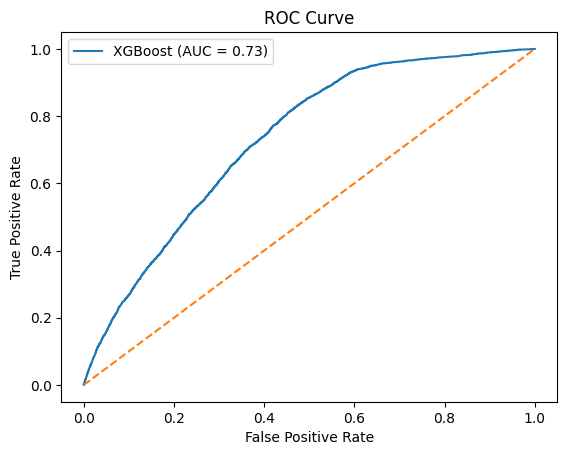

In [454]:
# Predict probabilities (important for ROC)
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# AUC Score
roc_auc = roc_auc_score(y_test, y_probs)

print("AUC Score:", roc_auc)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### ROC-AUC Interpretation
The ROC curve shows that the model achieves an Area Under the Curve (AUC) of approximately 0.73, indicating a good ability to distinguish between patients who attend and those who do not.

While this reflects reasonable discriminative performance, it is important to note that ROC-AUC can be misleading in imbalanced datasets, as it does not fully capture performance on the minority class.

Therefore, although the ROC result is acceptable, greater emphasis is placed on recall and Precision-Recall analysis to better evaluate the model’s effectiveness in detecting no-show cases.


## Precision-Recall Curve

---



To further evaluate model performance on imbalanced data, the Precision-Recall (PR) curve was used. This metric is particularly important in this context, as it focuses on the model's ability to correctly identify no-show cases while balancing precision and recall.

PR AUC: 0.3685576143802456


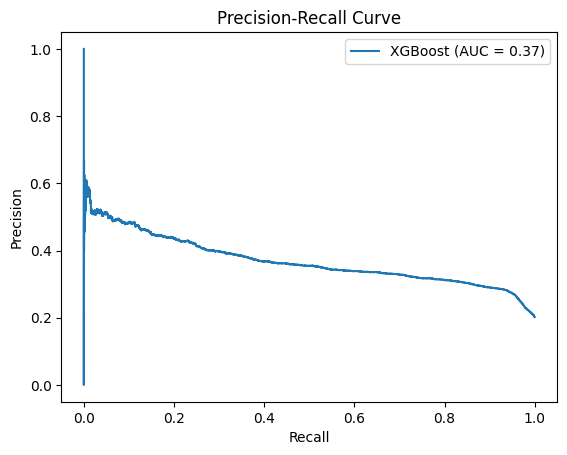

In [455]:
# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# PR AUC
pr_auc = auc(recall, precision)

print("PR AUC:", pr_auc)

# Plot
plt.figure()
plt.plot(recall, precision, label=f"XGBoost (AUC = {pr_auc:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

### Precision–Recall Interpretation

The Precision–Recall curve is particularly important in this study because the dataset is imbalanced and the main objective is to identify no-show cases. The PR AUC of approximately 0.37 is clearly above the class baseline (~0.20), indicating that the model performs meaningfully better than random selection in detecting patients at risk of missing appointments.

The curve also reflects a clear trade-off between recall and precision: increasing recall allows the model to detect more true no-show cases, but also increases the number of false positives. In this project, this trade-off is acceptable because missing a likely no-show case is operationally more costly than issuing an unnecessary alert.

Overall, the PR result supports the practical usefulness of the model, while also showing that precision remains an area for further improvement.

## Feature Importance Analysis

---



To better understand the model’s decision-making process, feature importance was analyzed using the XGBoost model. This helps identify which variables contribute the most to predicting no-show behavior.




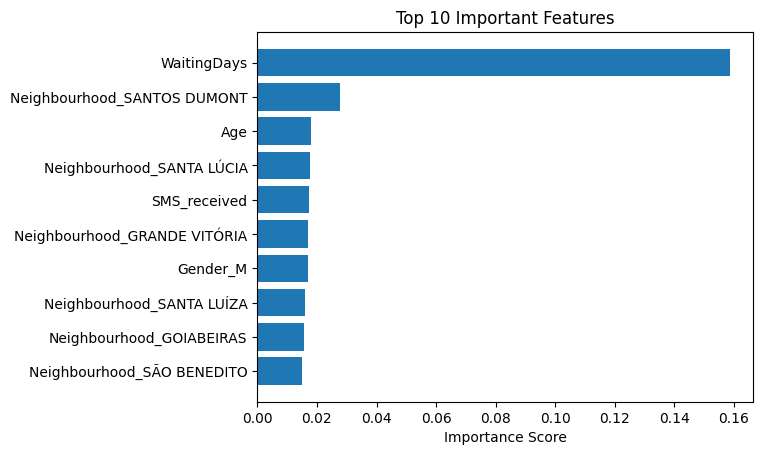

In [456]:
# Get feature importance
importances = xgb_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort and get top 10
top_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure()
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 10 Important Features")
plt.show()

### Feature Importance Interpretation

The feature importance analysis reveals that **WaitingDays** is the most influential variable in predicting no-show behavior. This suggests that longer waiting times between scheduling and appointment dates significantly increase the likelihood of patients missing their appointments.

Additionally, **SMS_received** plays an important role, indicating that reminder systems may influence patient attendance, although their effect may vary depending on other factors.

Demographic features such as **Age** also contribute to the prediction, suggesting that patient characteristics impact attendance behavior.

Furthermore, several **Neighbourhood** variables appear among the top features, highlighting the potential influence of geographic and socioeconomic factors on healthcare access and appointment adherence.

Overall, these findings align with real-world expectations, where logistical delays and patient-related factors play a key role in missed appointments.
This insight can support healthcare providers in designing targeted interventions, such as reducing waiting times or improving reminder systems.

## Programmatic Model Comparison Table
To ensure reproducibility, the final model comparison table was generated programmatically from the evaluation results rather than being entered manuall

In [457]:
# Generate model comparison table programmatically
model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall (No-show)": recall_score(y_test, y_pred),
        "Precision (No-show)": precision_score(y_test, y_pred),
        "F1-score (No-show)": f1_score(y_test, y_pred),
    },
    {
        "Model": "Balanced Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_balanced),
        "Recall (No-show)": recall_score(y_test, y_pred_balanced),
        "Precision (No-show)": precision_score(y_test, y_pred_balanced),
        "F1-score (No-show)": f1_score(y_test, y_pred_balanced),
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Recall (No-show)": recall_score(y_test, y_pred_rf),
        "Precision (No-show)": precision_score(y_test, y_pred_rf),
        "F1-score (No-show)": f1_score(y_test, y_pred_rf),
    },
    {
        "Model": "XGBoost",
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "Recall (No-show)": recall_score(y_test, y_pred_xgb),
        "Precision (No-show)": precision_score(y_test, y_pred_xgb),
        "F1-score (No-show)": f1_score(y_test, y_pred_xgb),
    }
])

# Optional: round values for cleaner presentation
model_comparison = model_comparison.sort_values(by="Recall (No-show)", ascending=False)

model_comparison

,Model,Accuracy,Recall (No-show),Precision (No-show),F1-score (No-show)
3,XGBoost,0.591586,0.824557,0.308595,0.449109
1,Balanced Logistic Regression,0.653563,0.578086,0.308797,0.402559
2,Random Forest,0.775164,0.211965,0.394331,0.275721
0,Logistic Regression,0.796019,0.015909,0.377660,0.030531


### Summary

The model comparison reveals clear differences in how each approach handles class imbalance.

**Logistic Regression** achieved the highest accuracy (0.79), but extremely low recall (0.02) for the no-show class, indicating a strong bias toward the majority class and poor detection of missed appointments.

**Balanced Logistic Regression** significantly improved recall (0.58), demonstrating the importance of incorporating class weighting to address imbalance, although this came at the cost of reduced precision and accuracy.

**Random Forest** showed moderate performance, with limited improvement in recall (0.21), indicating that it is not well-suited for detecting minority class instances in this context.

**XGBoost** achieved the highest recall (0.82), making it the most effective model for identifying no-show patients. However, this improvement comes with lower precision (0.31), reflecting an increased number of false positives. This trade-off is expected in imbalanced classification problems where sensitivity to the minority class is prioritized.

Overall, the results confirm that accuracy alone is not a reliable metric for this task, and recall is a more appropriate measure for evaluating model effectiveness in detecting no-show cases.

### Conclusion

---

✨

This project demonstrated the application of machine learning techniques to predict medical appointment no-show behavior using real-world healthcare data.

The analysis highlighted the significant impact of class imbalance on model performance and emphasized the importance of selecting appropriate evaluation metrics such as recall, ROC-AUC, and Precision-Recall curves.

Among the tested models, XGBoost provided the most effective performance in identifying no-show cases, achieving the highest recall. This makes it particularly suitable for practical deployment scenarios where detecting at-risk patients is more critical than minimizing false positives.

The results also revealed that while improving recall enhances detection capability, it introduces a trade-off with precision, underscoring the need for careful threshold and decision strategy selection in real-world applications.

Feature importance analysis indicated that waiting time (WaitingDays), SMS reminders, and demographic factors play a key role in influencing patient attendance behavior, offering actionable insights for healthcare providers.

Future work may include advanced encoding techniques, hyperparameter tuning, and the integration of additional clinical or behavioral features to further improve predictive performance.

Overall, this study provides a solid foundation for developing data-driven strategies to reduce missed appointments and improve healthcare system efficiency.
